In [1]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_samples, silhouette_score, adjusted_rand_score
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.ticker as ticker
import sys
project_root = Path().resolve().parent
sys.path.append(str(project_root / "src/02_data_preperation"))

from data_cleaning_helper import plot_heatmap

In [2]:
X_train = pd.read_csv(project_root / "data/cleaned_X_train.csv")
X_test = pd.read_csv(project_root / "data/cleaned_X_test.csv")
y_train = pd.read_csv(project_root / "data/cleaned_y_train.csv")


In [73]:
X_train

,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,holding_change_percent,direct_ownership,month_sin,month_cos
0,BDC,Biegacki Steven,2008-10-14,-0.246780,0.463601,False,True,False,-1.103909,False,-8.660254e-01,0.5
1,BDC,Biegacki Steven,2008-10-15,-0.244785,0.370486,False,True,False,1.786374,False,-8.660254e-01,0.5
2,BDC,Biegacki Steven,2008-10-22,-0.241934,0.351683,False,True,False,-1.103909,False,-8.660254e-01,0.5
3,BDC,Biegacki Steven,2008-10-22,-0.244785,0.296173,False,True,False,1.736727,False,-8.660254e-01,0.5
4,BDC,Biegacki Steven,2008-10-23,-0.244785,0.149351,False,True,False,1.675006,False,-8.660254e-01,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...
175066,PFHO,KUBOTA TOM,2019-12-31,-0.182073,-1.128180,True,True,True,-0.877515,True,-2.449294e-16,1.0
175067,MPB,Moisey Robert J,2019-12-31,-0.243188,0.582707,True,False,False,0.079170,True,-2.449294e-16,1.0
175068,MPB,KERWIN GREGORY M,2019-12-31,-0.246638,0.582707,True,False,False,-0.890183,True,-2.449294e-16,1.0
175069,MPB,Grubic Robert C,2019-12-31,-0.242704,0.582707,True,False,False,-0.463223,True,-2.449294e-16,1.0


In [82]:
X = X_train.select_dtypes(include=["integer", "float", "bool"]).values
idx = np.random.choice(len(X), 20_000, replace=False)
X_sub = X[idx]
silhouettes = []
for k in range(2, 11):
    km = MiniBatchKMeans(
        n_clusters=k,
        n_init=50,
        batch_size=2048,
        random_state=120
    )
    labels = km.fit_predict(X)
    silhouettes.append(silhouette_score(X_sub, labels[idx]))

silhouettes

[0.15715483013047787,
 0.1825690218698466,
 0.23447176282167376,
 0.19907038766119511,
 0.1763702420176645,
 0.16701692443722976,
 0.17992980221445723,
 0.1783375222453913,
 0.1822973954757076]

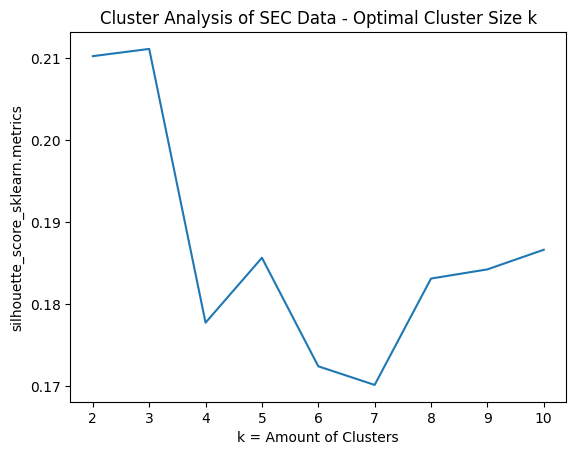

In [81]:
ys = silhouettes
xs = [x for x in range(2, 11)]
plt.plot(xs, ys)
plt.title("Cluster Analysis of SEC Data - Optimal Cluster Size k")
plt.xlabel("k = Amount of Clusters")
plt.ylabel("silhouette_score_sklearn.metrics")
plt.savefig(project_root / 'exports/clustera_analysis_silhouette_scores.png', dpi=500)
plt.show()


In [83]:
Ks = range(2, 5)

means = []
stds = []

for k in Ks:
    scores = []

    for seed in range(30):

        km = KMeans(
            n_clusters=k,
            n_init=20,
            random_state=seed
        )

        labels = km.fit_predict(X)

        scores.append(
            silhouette_score(X_sub, labels[idx])
        )

    means.append(np.mean(scores))
    stds.append(np.std(scores))

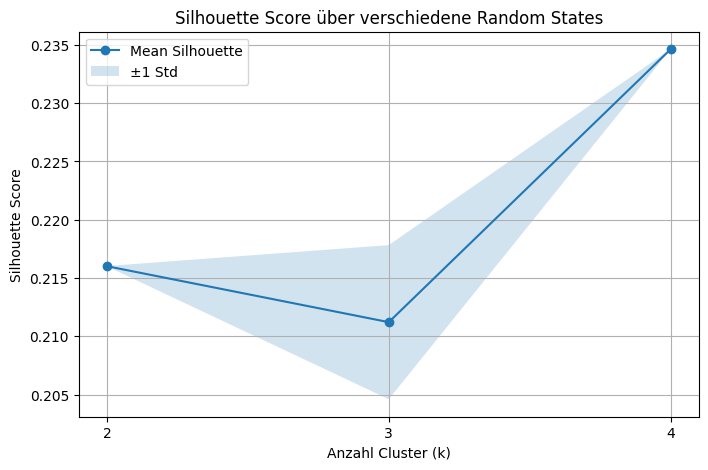

In [88]:
plt.figure(figsize=(8, 5))

plt.plot(Ks, means, marker="o", label="Mean Silhouette")

plt.fill_between(
    Ks,
    np.array(means) - np.array(stds),
    np.array(means) + np.array(stds),
    alpha=0.2,
    label="±1 Std"
)

plt.xticks(Ks)
plt.xlabel("Anzahl Cluster (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score über verschiedene Random States")
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
X = X_train.select_dtypes(include=["integer", "float", "bool"]).values

k_values = range(2, 6)

stability = {}

for k in k_values:

    labels_list = []

    for seed in range(20):

        km = KMeans(
            n_clusters=k,
            n_init=20,
            random_state=seed
        )

        labels = km.fit_predict(X)
        labels_list.append(labels)

    aris = []

    for i in range(len(labels_list)):
        for j in range(i + 1, len(labels_list)):
            aris.append(
                adjusted_rand_score(
                    labels_list[i],
                    labels_list[j]
                )
            )

    stability[k] = np.mean(aris)

print(stability)

{2: np.float64(0.999672104569706), 3: np.float64(0.7209407381425101), 4: np.float64(0.9998747344126666), 5: np.float64(0.9709406846716794)}


In [ ]:
kmeans = KMeans(
    n_clusters=4,
    init="k-means++",
    n_init=30,
    random_state=42
)

feature_cols = X_train.select_dtypes(include=["integer", "float", "bool"]).columns

X_train["kmeans"] = kmeans.fit_predict(X)

cluster_centers = (
    pd.DataFrame(kmeans.cluster_centers_, columns=feature_cols)
      .assign(cluster=lambda d: d.index)
)

cluster_centers.to_csv(project_root / 'cluster_centers.csv', index=False)


In [7]:
cluster_centers

,amounts.shares,amounts.pricePerShare,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,holding_change_percent,direct_ownership,month_sin,month_cos,cluster
0,-0.175064,1.143896,0.324479,0.183270,0.101136,-0.372658,0.249335,-0.106241,0.193175,0
1,-0.126071,-0.728775,0.649267,0.523397,0.532505,-0.807486,0.583977,-0.057239,0.006976,1
2,-0.039261,-0.183281,0.697043,0.360730,0.082473,1.216581,0.758000,-0.023319,-0.032258,2
3,6.673941,-0.215967,0.381150,0.118503,0.787595,0.658731,0.362786,-0.029915,-0.005488,3


In [6]:
X_train.groupby("kmeans").size()

kmeans
0    50787
1    64555
2    56843
3     2886
dtype: int64

In [9]:
X = X_test.select_dtypes(include=["integer", "float", "bool"]).values
X_test["kmeans"] = kmeans.predict(X)

In [12]:
kmeans_export_for_eda = pd.concat([X_train["kmeans"], X_test["kmeans"]])

kmeans_export_for_eda.to_csv(project_root / "data/k_means_eda_df.csv", index=False)

In [13]:
train_df = X_train.join(y_train, how="left")
train_df


,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,holding_change_percent,direct_ownership,...,target_3,target_4,target_5,target_6,target_7,target_8,target_9,target_10,target_20,target_60
0,BDC,Biegacki Steven,2008-10-14,-0.246780,0.463601,False,True,False,-1.103909,False,...,False,False,False,False,False,False,False,False,False,False
1,BDC,Biegacki Steven,2008-10-15,-0.244785,0.370486,False,True,False,1.786374,False,...,False,False,False,False,False,False,False,False,False,False
2,BDC,Biegacki Steven,2008-10-22,-0.241934,0.351683,False,True,False,-1.103909,False,...,False,False,False,False,False,False,False,False,False,False
3,BDC,Biegacki Steven,2008-10-22,-0.244785,0.296173,False,True,False,1.736727,False,...,False,False,False,False,False,False,False,False,False,False
4,BDC,Biegacki Steven,2008-10-23,-0.244785,0.149351,False,True,False,1.675006,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175066,PFHO,KUBOTA TOM,2019-12-31,-0.182073,-1.128180,True,True,True,-0.877515,True,...,False,False,False,True,True,True,True,True,True,False
175067,MPB,Moisey Robert J,2019-12-31,-0.243188,0.582707,True,False,False,0.079170,True,...,False,False,False,False,False,False,False,False,False,False
175068,MPB,KERWIN GREGORY M,2019-12-31,-0.246638,0.582707,True,False,False,-0.890183,True,...,False,False,False,False,False,False,False,False,False,False
175069,MPB,Grubic Robert C,2019-12-31,-0.242704,0.582707,True,False,False,-0.463223,True,...,False,False,False,False,False,False,False,False,False,False


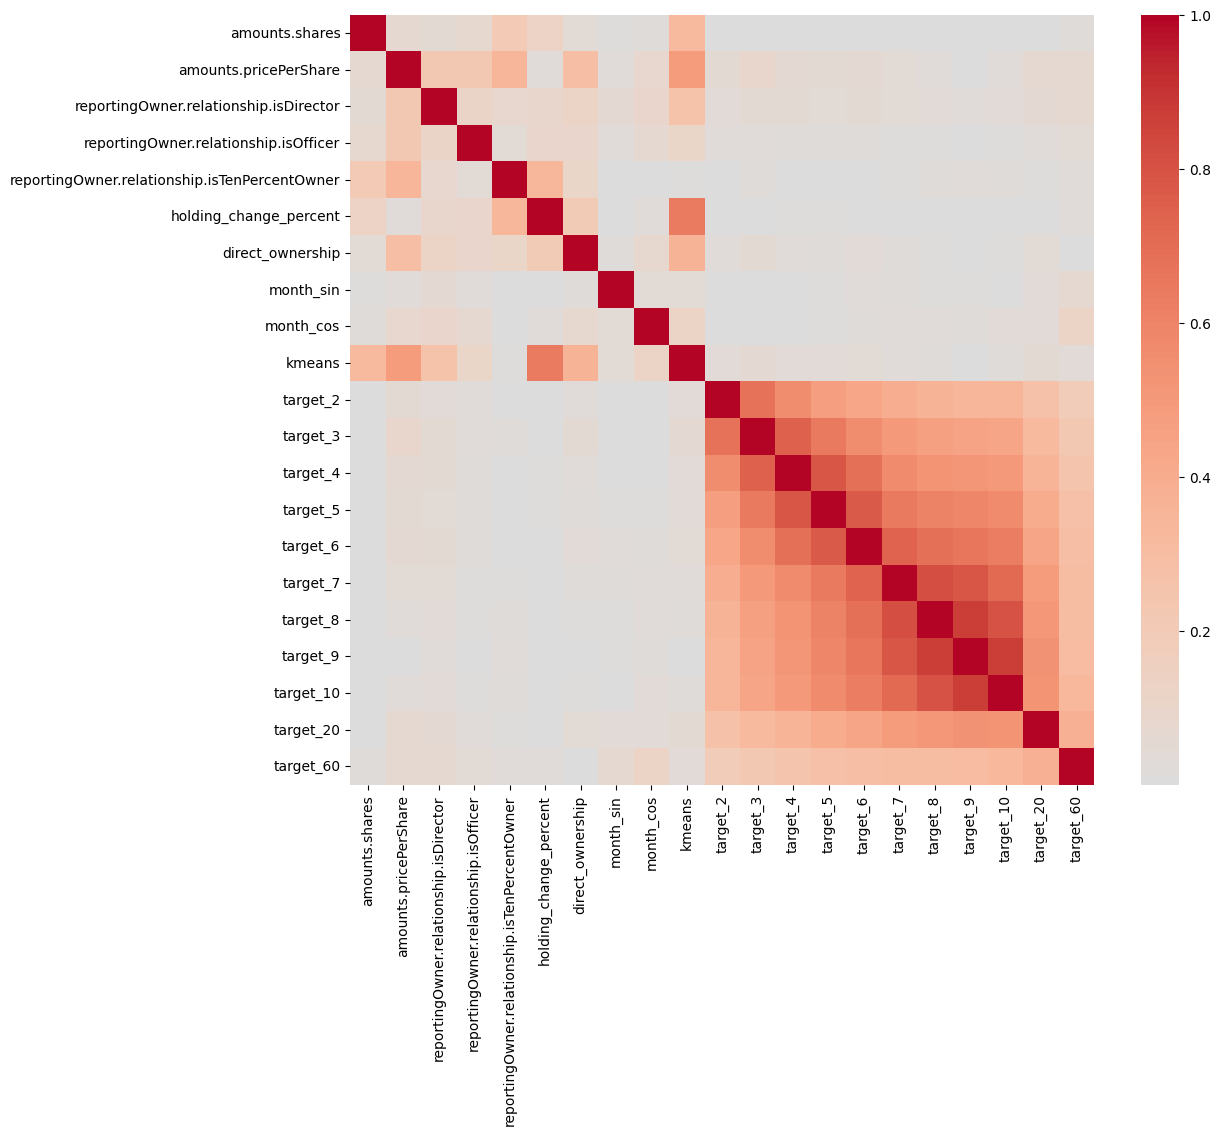

In [15]:
plot_heatmap(train_df.select_dtypes(include=["integer", "float", "bool"]))

In [16]:
X_train.to_csv(project_root / "data/cleaned_X_train.csv", index=False)
X_test.to_csv(project_root / "data/cleaned_X_test.csv", index=False)